# Introduction to Tidyverse

* Load
the tidyverse by running:

In [1]:
library(tidyverse, warn.conflicts = FALSE)

Registered S3 methods overwritten by 'ggplot2':
  method         from 
  [.quosures     rlang
  c.quosures     rlang
  print.quosures rlang
Registered S3 method overwritten by 'rvest':
  method            from
  read_xml.response xml2
-- Attaching packages --------------------------------------- tidyverse 1.2.1 --
v ggplot2 3.1.1       v purrr   0.3.2  
v tibble  2.1.1       v dplyr   0.8.0.1
v tidyr   0.8.3       v stringr 1.4.0  
v readr   1.3.1       v forcats 0.4.0  
-- Conflicts ------------------------------------------ tidyverse_conflicts() --
x dplyr::filter() masks stats::filter()
x dplyr::lag()    masks stats::lag()


* "warn.conflicts = FALSE" will suppress the soft warnings.

### The penguins Data Frame

In addition to tidyverse, we will use the Palmer penguins dataset containing body measurements for
penguins on three islands in the Palmer Archipelago

### Loading the dataset

In [2]:
install.packages("palmerpenguins")
library(palmerpenguins, warn.conflicts = FALSE)
data("penguins")

Warning message:
"unable to access index for repository https://cran.r-project.org/bin/windows/contrib/3.6:
installing the source package 'palmerpenguins'bin/windows/contrib/3.6/PACKAGES'"



### Viewing the DataFrame

In [3]:
penguins

species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
Adelie,Torgersen,39.1,18.7,181,3750,male,2007
Adelie,Torgersen,39.5,17.4,186,3800,female,2007
Adelie,Torgersen,40.3,18.0,195,3250,female,2007
Adelie,Torgersen,NA,NA,NA,NA,NA,2007
Adelie,Torgersen,36.7,19.3,193,3450,female,2007
Adelie,Torgersen,39.3,20.6,190,3650,male,2007
Adelie,Torgersen,38.9,17.8,181,3625,female,2007
Adelie,Torgersen,39.2,19.6,195,4675,male,2007
Adelie,Torgersen,34.1,18.1,193,3475,NA,2007
Adelie,Torgersen,42.0,20.2,190,4250,NA,2007


* For an alternative view, where you
can see all variables and the first few observations of each variable, use
glimpse()

In [4]:
glimpse(penguins)

Observations: 344
Variables: 8
$ species           <fct> Adelie, Adelie, Adelie, Adelie, Adelie, Adelie, A...
$ island            <fct> Torgersen, Torgersen, Torgersen, Torgersen, Torge...
$ bill_length_mm    <dbl> 39.1, 39.5, 40.3, NA, 36.7, 39.3, 38.9, 39.2, 34....
$ bill_depth_mm     <dbl> 18.7, 17.4, 18.0, NA, 19.3, 20.6, 17.8, 19.6, 18....
$ flipper_length_mm <int> 181, 186, 195, NA, 193, 190, 181, 195, 193, 190, ...
$ body_mass_g       <int> 3750, 3800, 3250, NA, 3450, 3650, 3625, 4675, 347...
$ sex               <fct> male, female, female, NA, female, male, female, m...
$ year              <int> 2007, 2007, 2007, 2007, 2007, 2007, 2007, 2007, 2...


Variables
* species: 
A penguin’s species (Adelie, Chinstrap, or Gentoo)
* flipper_length_mm: 
The length of a penguin’s flipper, in millimeters
* body_mass_g: 
The body mass of a penguin, in grams

### Visualizing data with ggplot

##### Scatter plot

In [5]:
colnames(penguins)

[1] "species"           "island"            "bill_length_mm"   
[4] "bill_depth_mm"     "flipper_length_mm" "body_mass_g"      
[7] "sex"               "year"

In [6]:
head(penguins)

species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
Adelie,Torgersen,39.1,18.7,181,3750,male,2007
Adelie,Torgersen,39.5,17.4,186,3800,female,2007
Adelie,Torgersen,40.3,18.0,195,3250,female,2007
Adelie,Torgersen,NA,NA,NA,NA,NA,2007
Adelie,Torgersen,36.7,19.3,193,3450,female,2007
Adelie,Torgersen,39.3,20.6,190,3650,male,2007


Warning message:
"Removed 2 rows containing missing values (geom_point)."

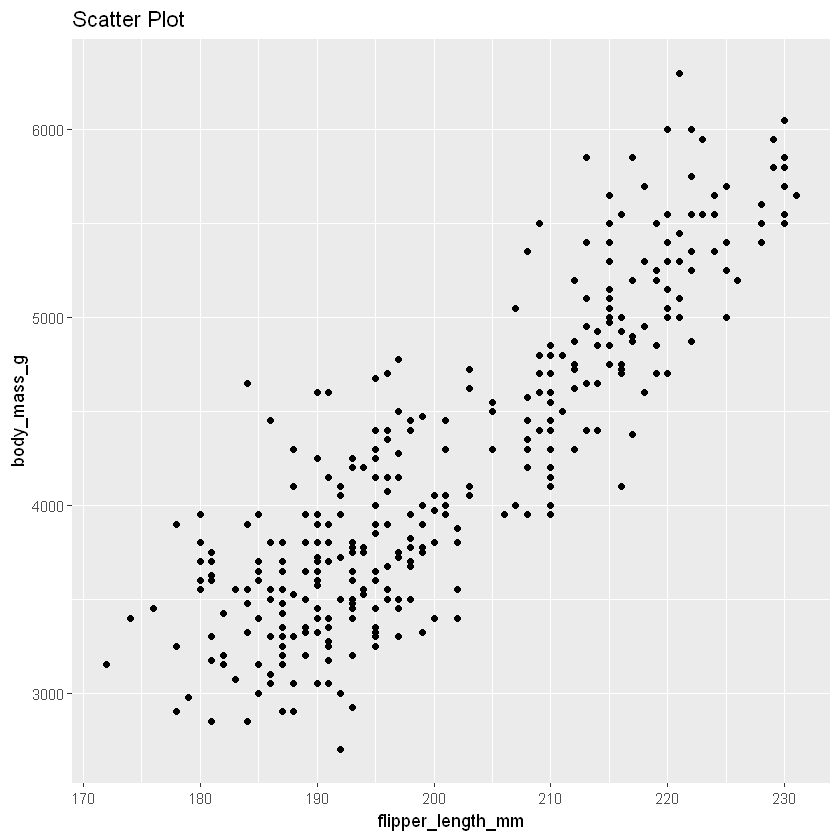

In [7]:
ggplot( 
    data=penguins,
    mapping = aes(x = flipper_length_mm,y = body_mass_g)
)+geom_point()+labs(title = "Scatter Plot")

Warning message:
"Removed 2 rows containing missing values (geom_path)."

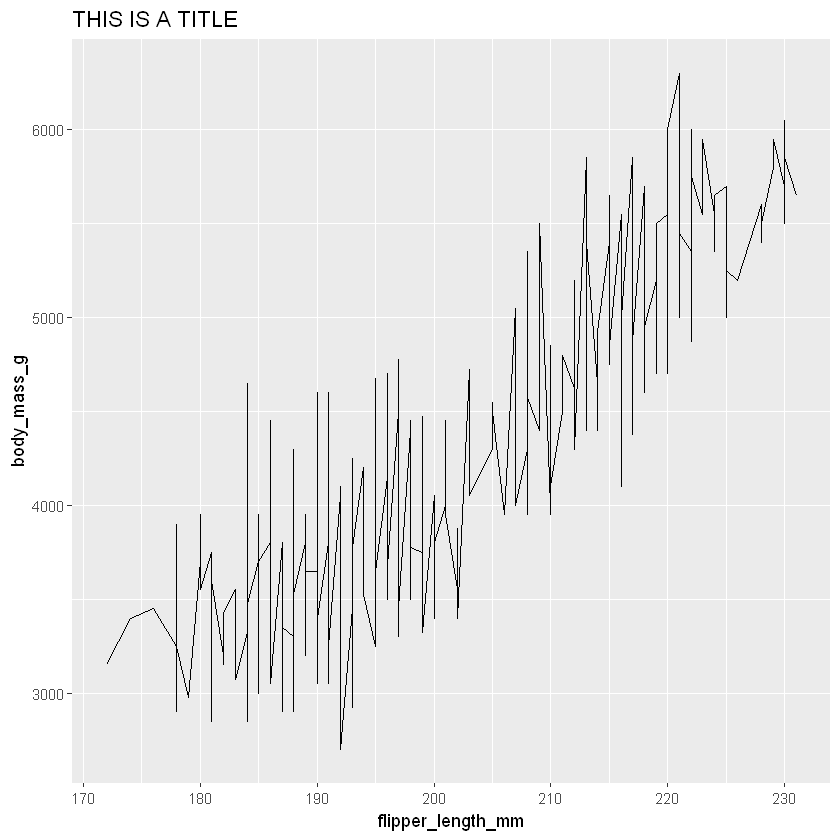

In [8]:
ggplot(
    penguins,aes(x=flipper_length_mm,y = body_mass_g)
)+geom_line()+labs(title = "THIS IS A TITLE")

In [9]:
penguins <- na.omit(penguins)

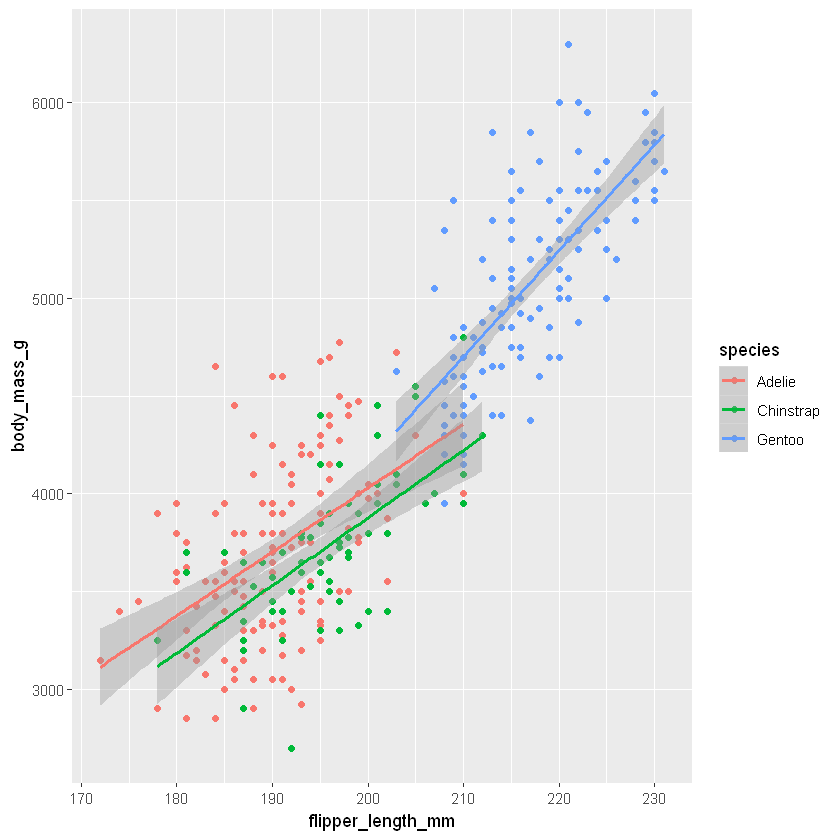

In [10]:
ggplot(
    penguins,aes(x = flipper_length_mm, y = body_mass_g, color = species)
)+ 
geom_point()+
geom_smooth(method = "lm")

##### Making a combined regression line for the plot

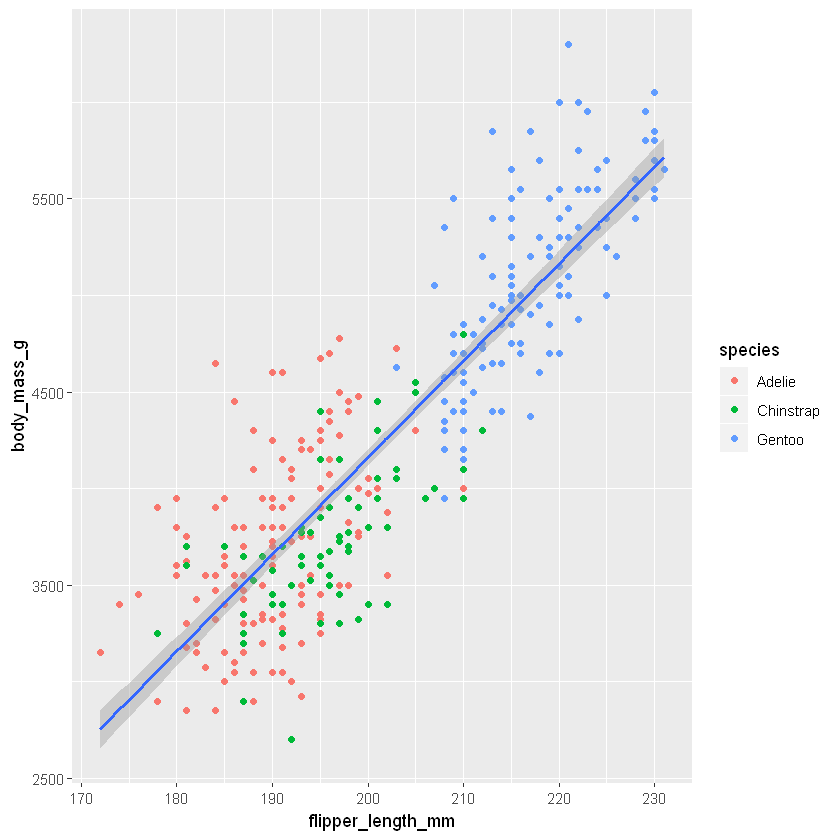

In [11]:
ggplot(
    penguins,aes(x = flipper_length_mm, y = body_mass_g)
)+ 
geom_point(mapping = aes(color = species))+
geom_smooth(method = "lm")

##### Changing the shape of the data points

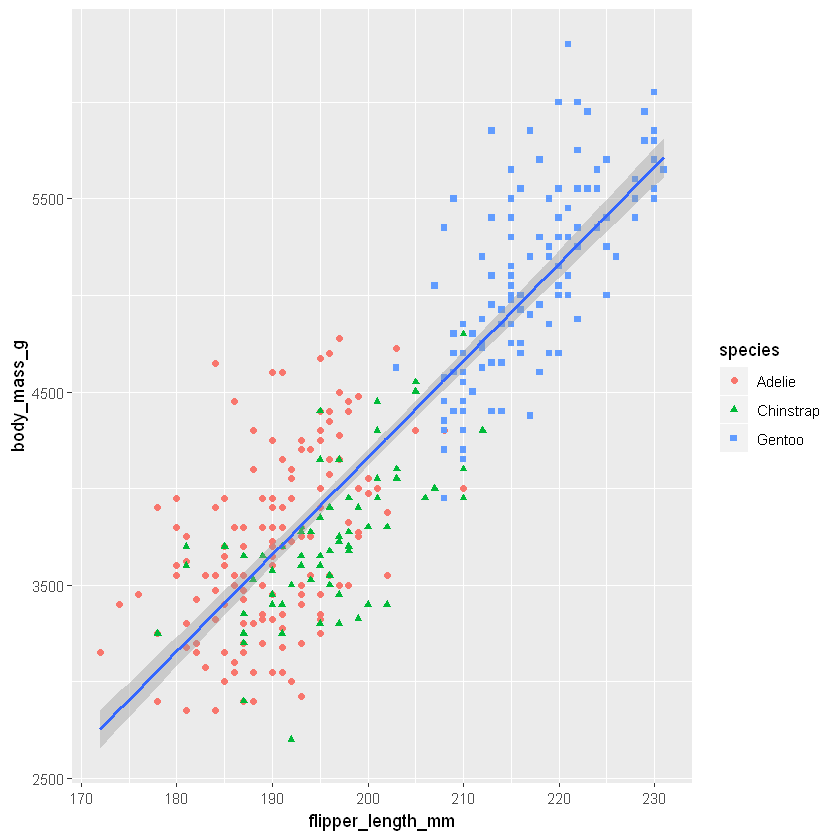

In [12]:
ggplot(
    penguins,aes(x = flipper_length_mm, y = body_mass_g)
)+ 
geom_point(mapping = aes(color = species, shape = species))+
geom_smooth(method = "lm")

##### Adding the labels

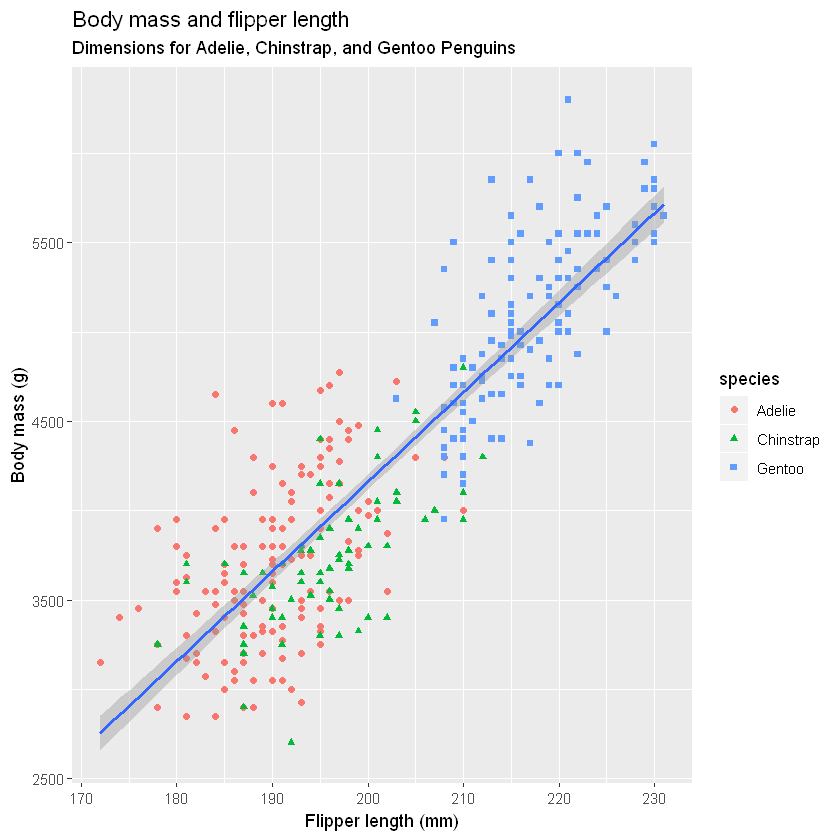

In [13]:
ggplot(
    penguins,aes(x = flipper_length_mm, y = body_mass_g)
)+ 
geom_point(mapping = aes(color = species, shape = species))+
geom_smooth(method = "lm")+ labs(

title = "Body mass and flipper length",
subtitle = "Dimensions for Adelie, Chinstrap, and Gentoo Penguins",
x = "Flipper length (mm)", y = "Body mass (g)"

)

#### Fact Wrap

* The facet approach partitions a plot into a matrix of panels. Each panel shows a different subset of the data

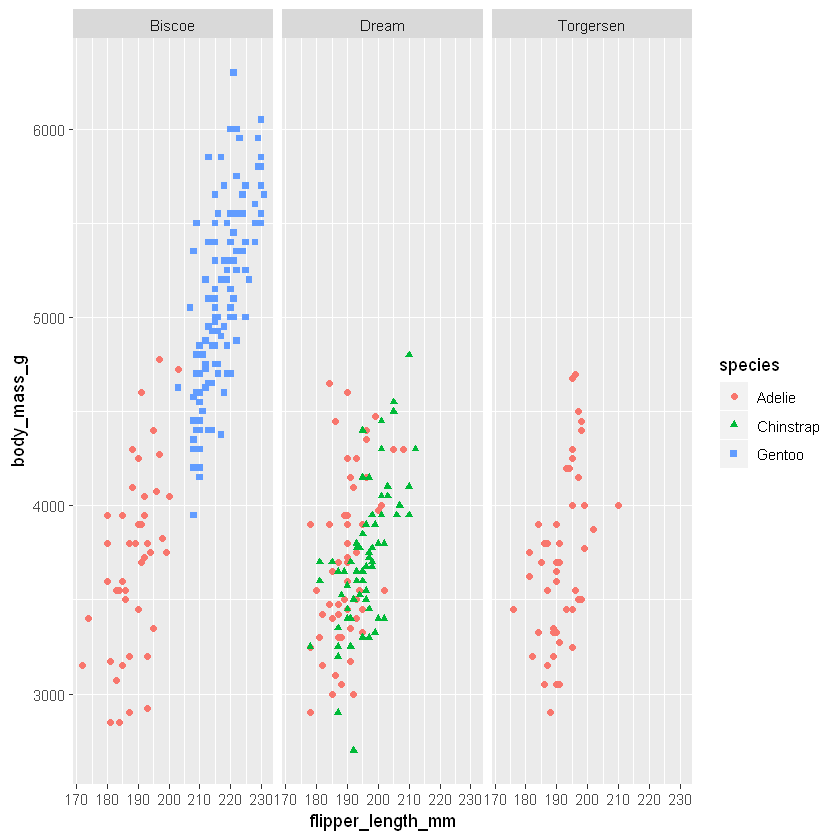

In [14]:
ggplot(penguins, aes(x = flipper_length_mm, y = body_mass_g)) +
geom_point(aes(color = species, shape = species), na.rm = TRUE) +
facet_wrap(~island)

### Visualizing the distributions

#### Categorical variables

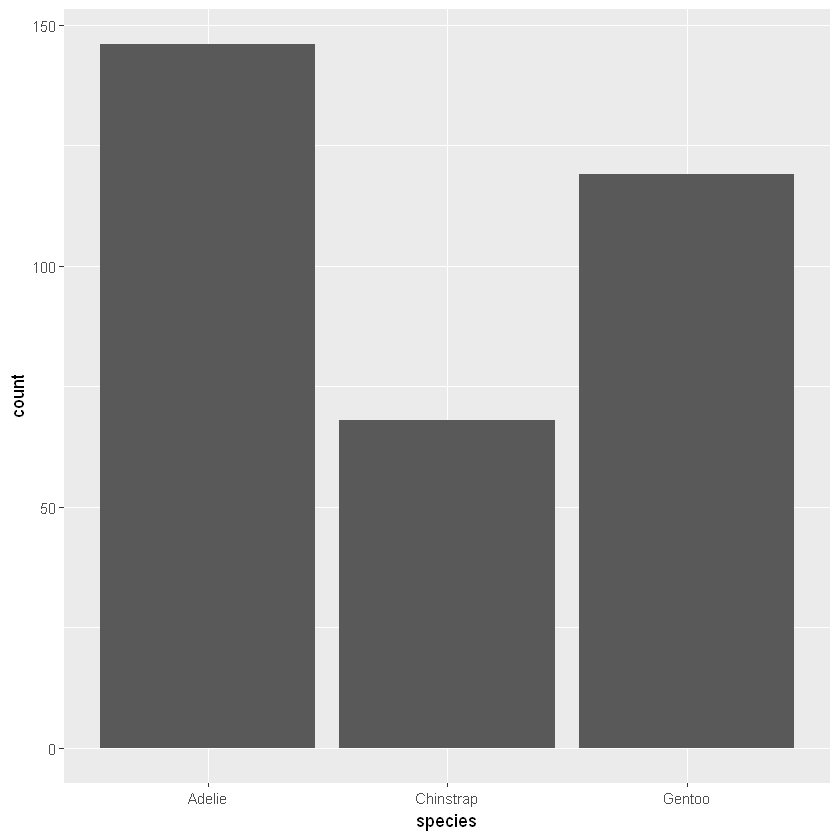

In [15]:
ggplot(penguins, aes(x = species))+ geom_bar()

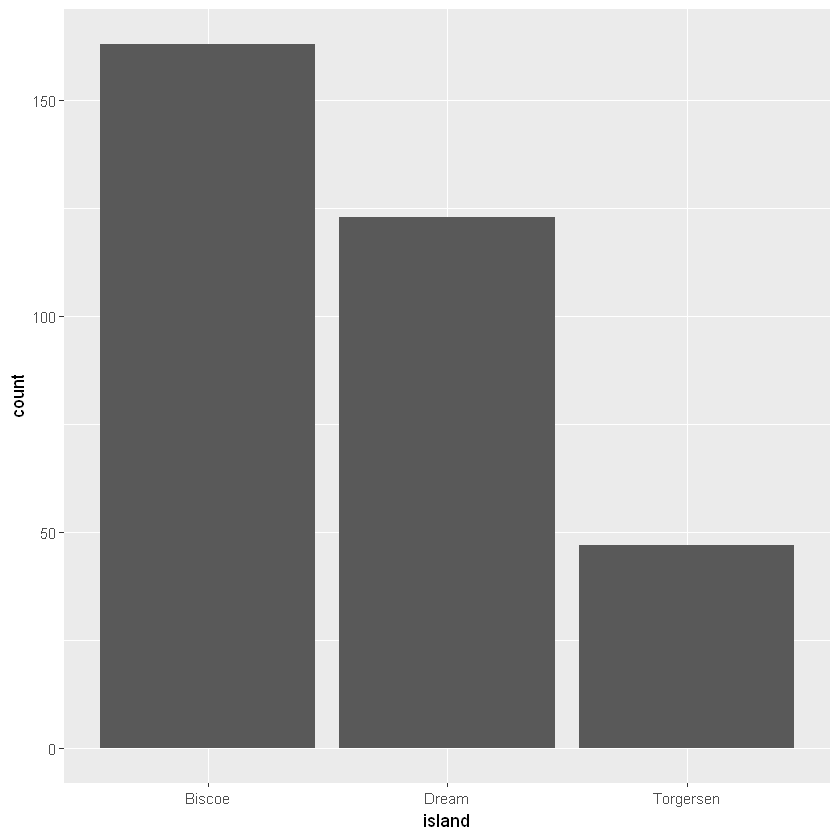

In [16]:
ggplot(
    data = penguins,
    aes(x = island)
)+geom_bar()

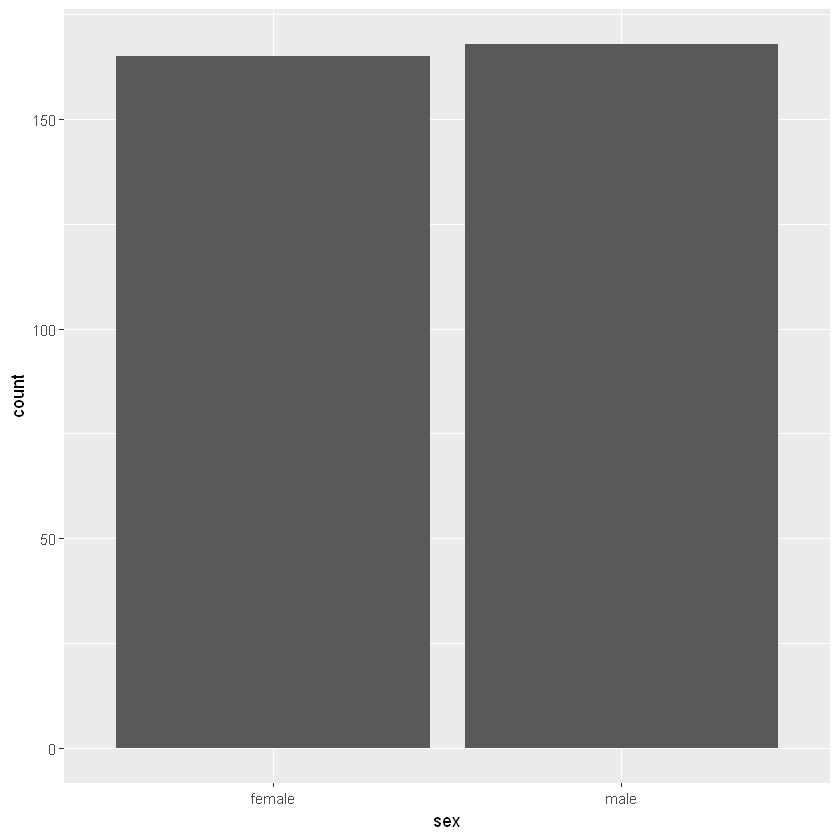

In [17]:
ggplot(
    data = penguins,
    aes(x = sex)
)+ geom_bar()

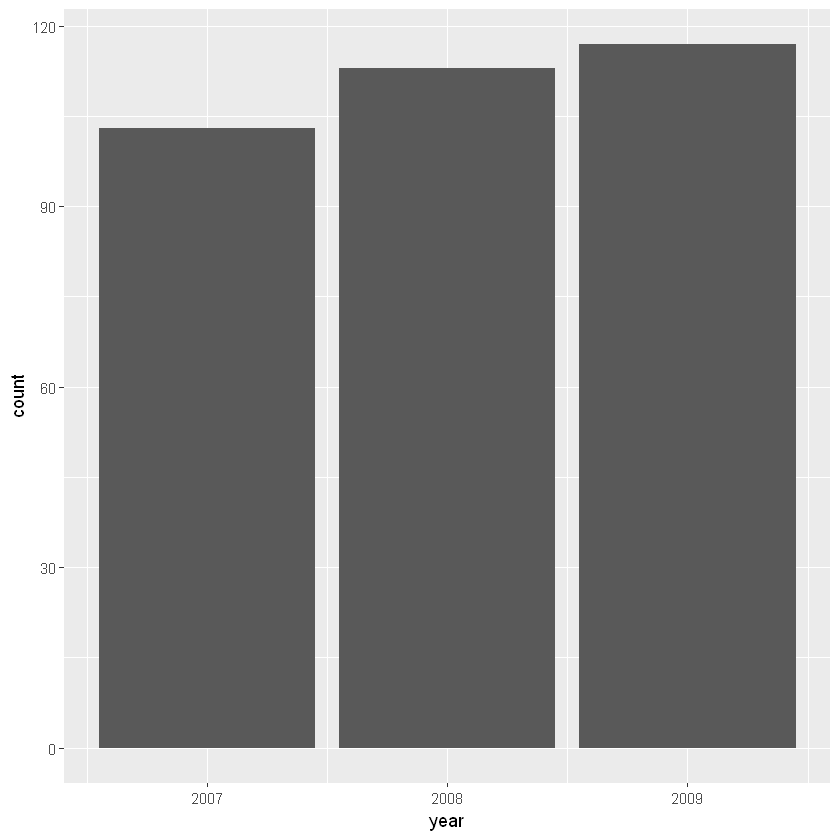

In [18]:
ggplot(
    data = penguins, 
    aes(x = year)
)+ geom_bar()

In [19]:
head(penguins)

species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
Adelie,Torgersen,39.1,18.7,181,3750,male,2007
Adelie,Torgersen,39.5,17.4,186,3800,female,2007
Adelie,Torgersen,40.3,18.0,195,3250,female,2007
Adelie,Torgersen,36.7,19.3,193,3450,female,2007
Adelie,Torgersen,39.3,20.6,190,3650,male,2007
Adelie,Torgersen,38.9,17.8,181,3625,female,2007


###### Ordering the Bar chart

* Customizing the size of the plot using the following code.

In [20]:
options(repr.plot.width=15, repr.plot.height=8)

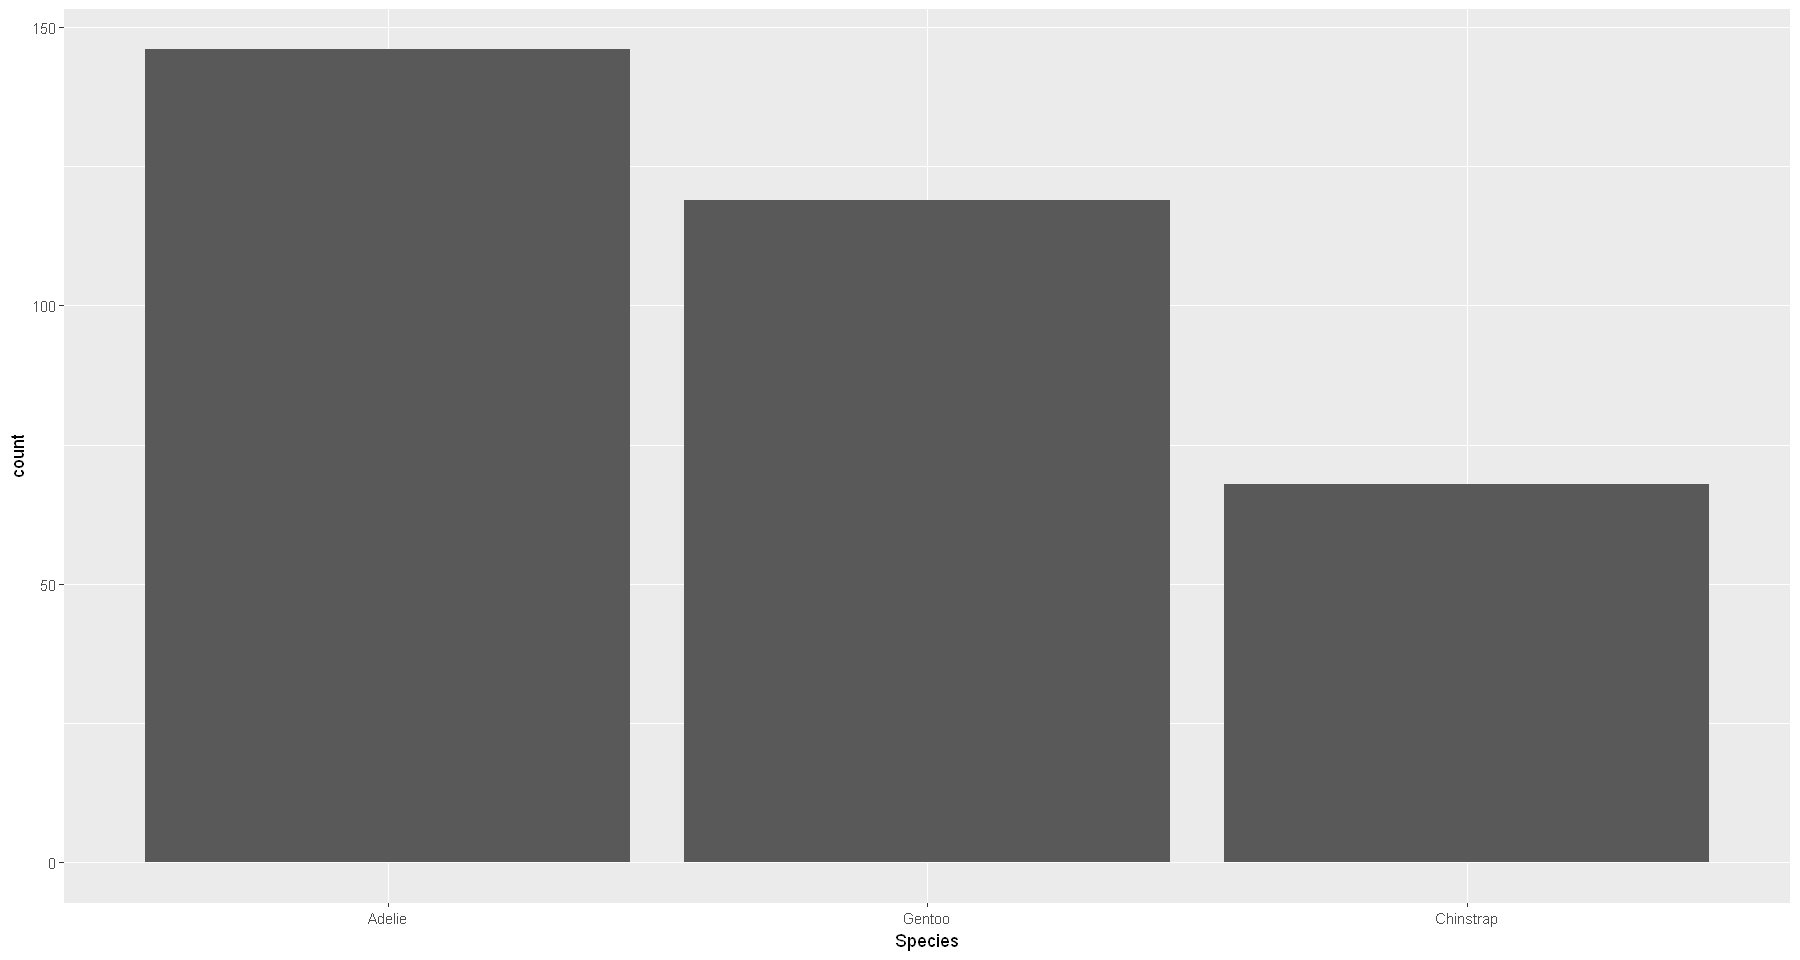

In [21]:
ggplot(penguins, aes(x = fct_infreq(species))) + geom_bar() + labs(x="Species")

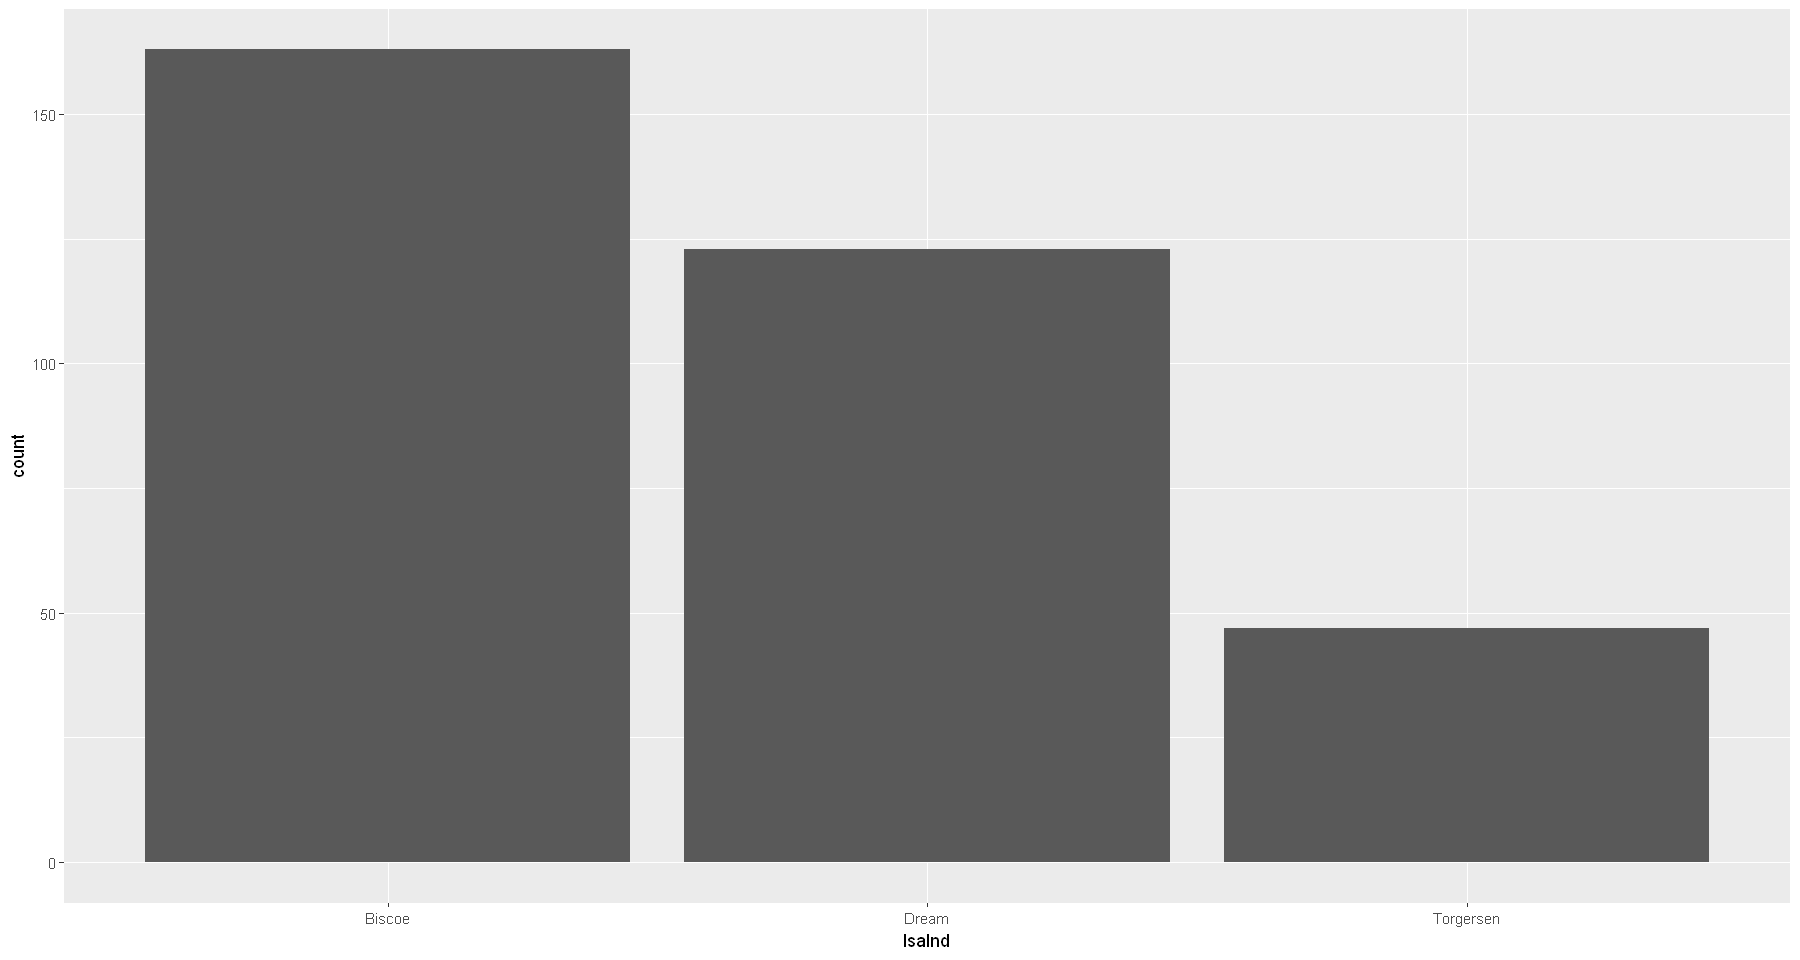

In [22]:
ggplot(
    data = penguins,
    aes(x = fct_infreq(island))
)+geom_bar() + labs(x="Isalnd")

#### Numerical values

##### Histogram

In [23]:
options(repr.plot.width = 6, repr.plot.height = 4)

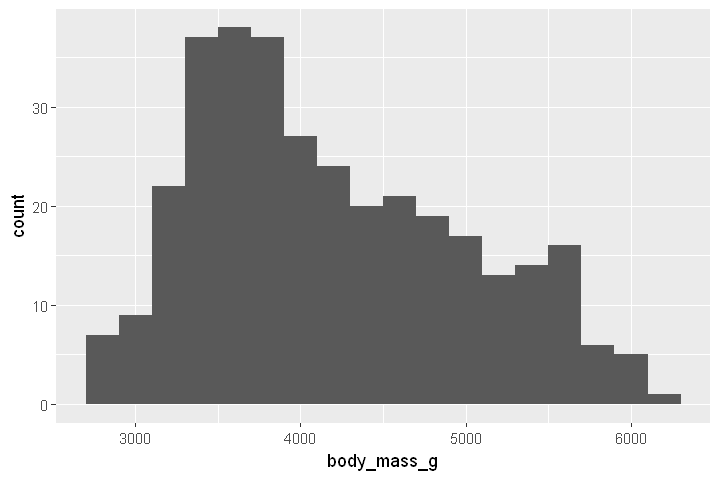

In [24]:
ggplot(penguins, aes(x =  body_mass_g))+ 
geom_histogram(binwidth = 200 )

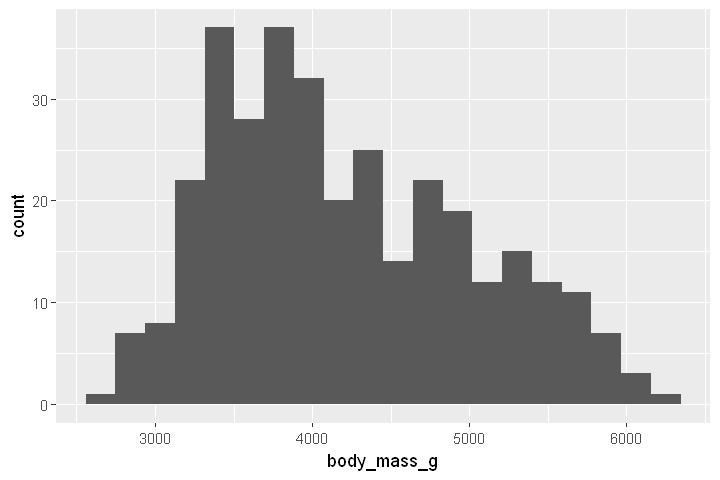

In [25]:
ggplot(penguins, aes(x =  body_mass_g))+ 
geom_histogram(bins = 20 )

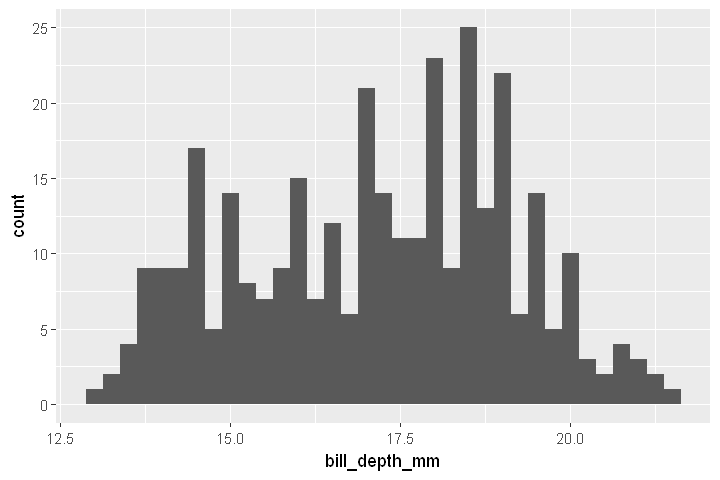

In [26]:
ggplot(data = penguins,
      aes(x = bill_depth_mm))+ geom_histogram(binwidth = 0.25)

In [27]:
head(penguins, 10)

species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
Adelie,Torgersen,39.1,18.7,181,3750,male,2007
Adelie,Torgersen,39.5,17.4,186,3800,female,2007
Adelie,Torgersen,40.3,18.0,195,3250,female,2007
Adelie,Torgersen,36.7,19.3,193,3450,female,2007
Adelie,Torgersen,39.3,20.6,190,3650,male,2007
Adelie,Torgersen,38.9,17.8,181,3625,female,2007
Adelie,Torgersen,39.2,19.6,195,4675,male,2007
Adelie,Torgersen,41.1,17.6,182,3200,female,2007
Adelie,Torgersen,38.6,21.2,191,3800,male,2007
Adelie,Torgersen,34.6,21.1,198,4400,male,2007


##### Density Plot

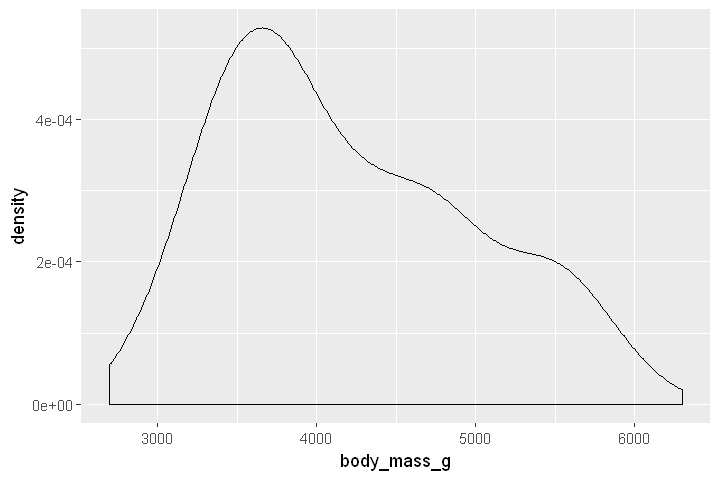

In [28]:
ggplot(penguins, aes(x = body_mass_g))+ geom_density()

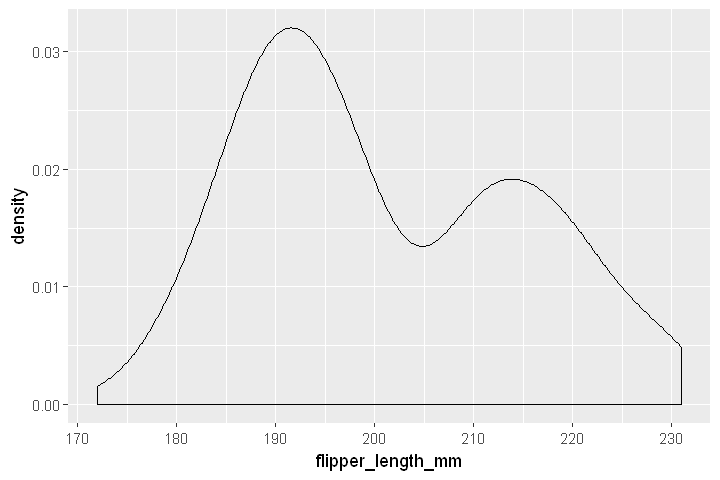

In [29]:
ggplot(penguins,
      aes(x = flipper_length_mm)) + geom_density()

##### Changing the color

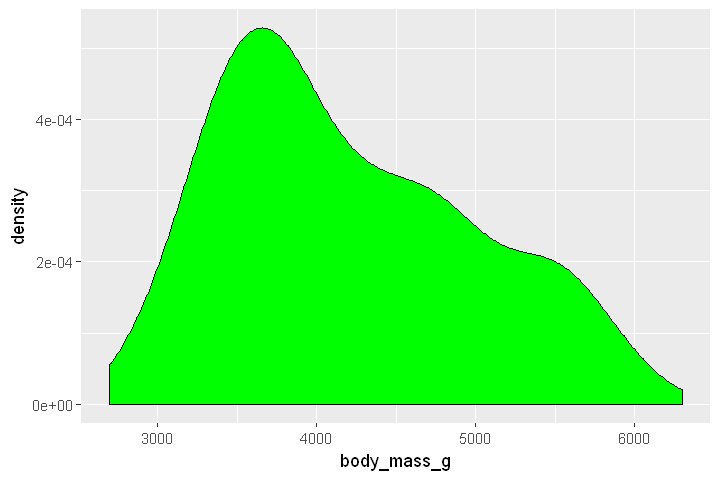

In [30]:
ggplot(penguins, aes(x = body_mass_g))+ geom_density(fill = "green")

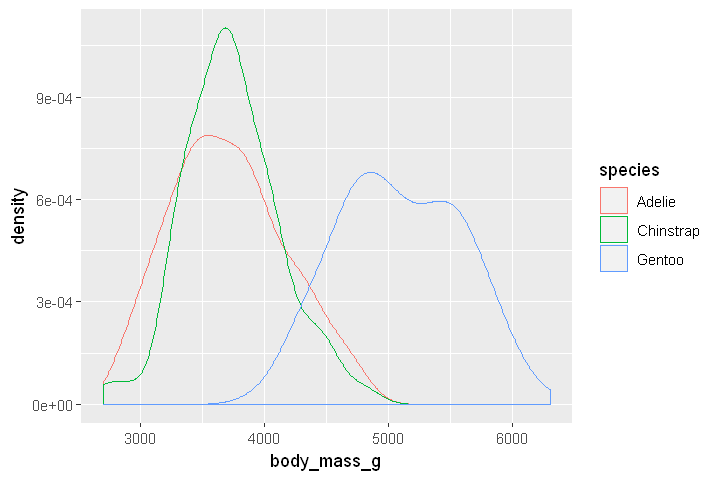

In [31]:
ggplot(penguins, aes(x = body_mass_g, color = species))+ geom_density()

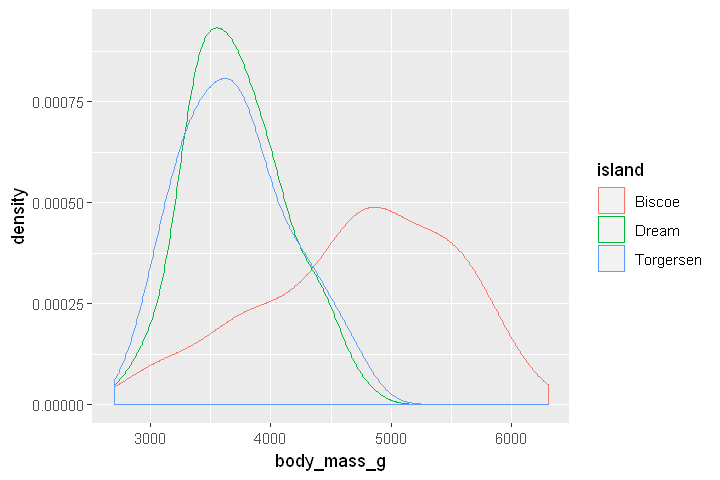

In [32]:
ggplot(penguins, aes(x = body_mass_g, color = island))+ geom_density()

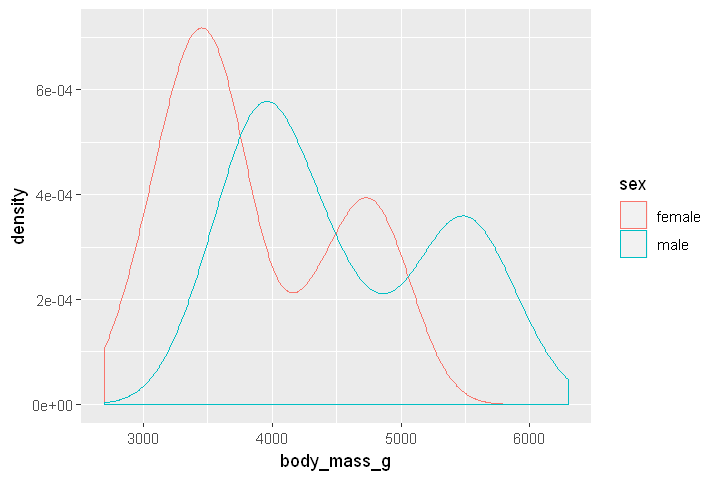

In [33]:
ggplot(penguins, aes(x = body_mass_g, color = sex))+ geom_density()

In [34]:
head(penguins, 10)

species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
Adelie,Torgersen,39.1,18.7,181,3750,male,2007
Adelie,Torgersen,39.5,17.4,186,3800,female,2007
Adelie,Torgersen,40.3,18.0,195,3250,female,2007
Adelie,Torgersen,36.7,19.3,193,3450,female,2007
Adelie,Torgersen,39.3,20.6,190,3650,male,2007
Adelie,Torgersen,38.9,17.8,181,3625,female,2007
Adelie,Torgersen,39.2,19.6,195,4675,male,2007
Adelie,Torgersen,41.1,17.6,182,3200,female,2007
Adelie,Torgersen,38.6,21.2,191,3800,male,2007
Adelie,Torgersen,34.6,21.1,198,4400,male,2007


##### Adding more aesthetics

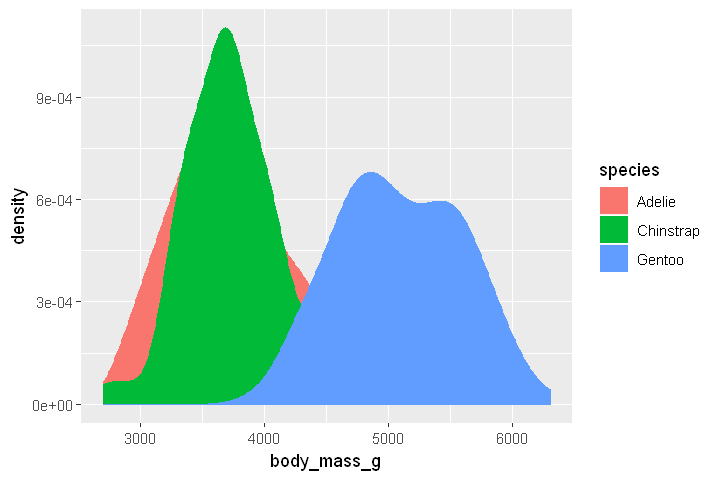

In [35]:
ggplot(penguins, aes(x = body_mass_g, color = species, fill = species))+ geom_density()

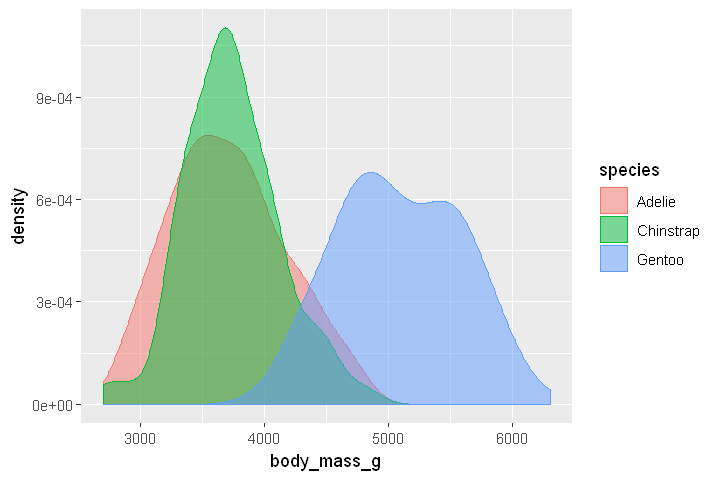

In [36]:
ggplot(penguins, aes(x = body_mass_g, color = species, fill = species))+ geom_density(alpha = 0.5)

##### Box Plots

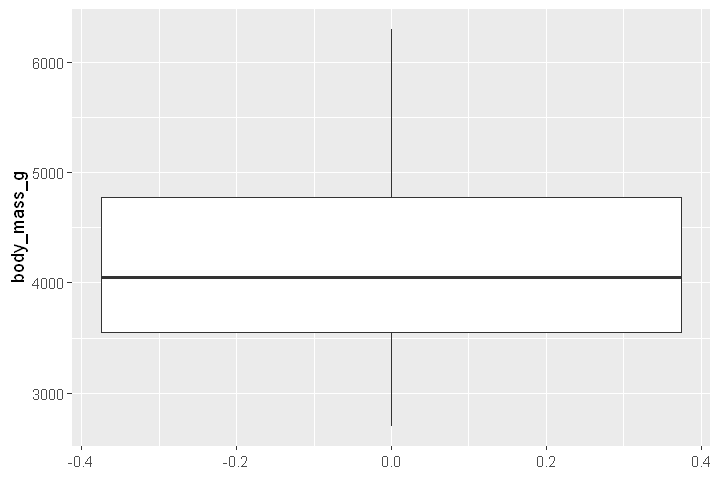

In [37]:
ggplot(penguins, aes(y = body_mass_g))+ geom_boxplot()

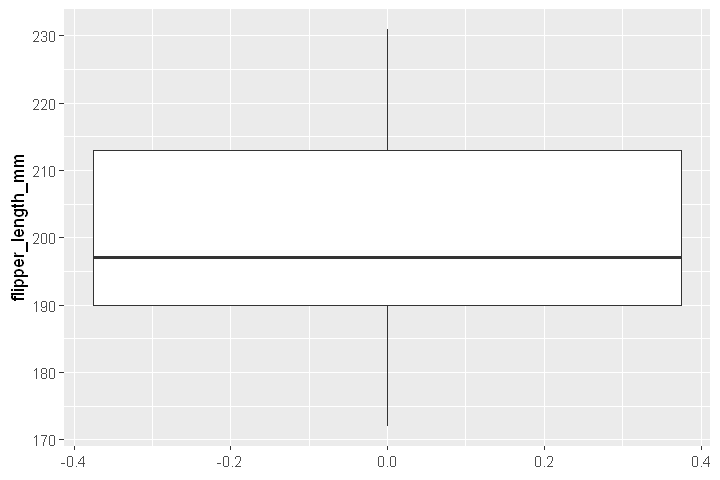

In [38]:
ggplot(data = penguins,
      aes(y = flipper_length_mm))+ geom_boxplot()

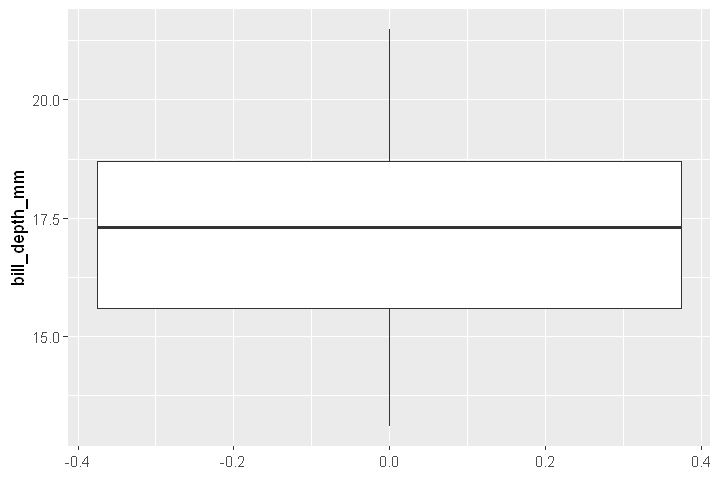

In [39]:
ggplot(data = penguins,
       aes(y = bill_depth_mm)) + geom_boxplot()

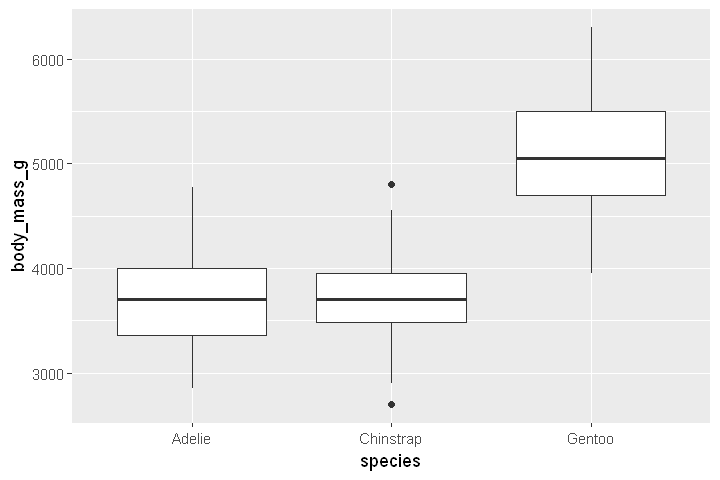

In [40]:
ggplot(penguins, aes(x = species, y = body_mass_g))+ geom_boxplot()

#### Stacked Bar Chart

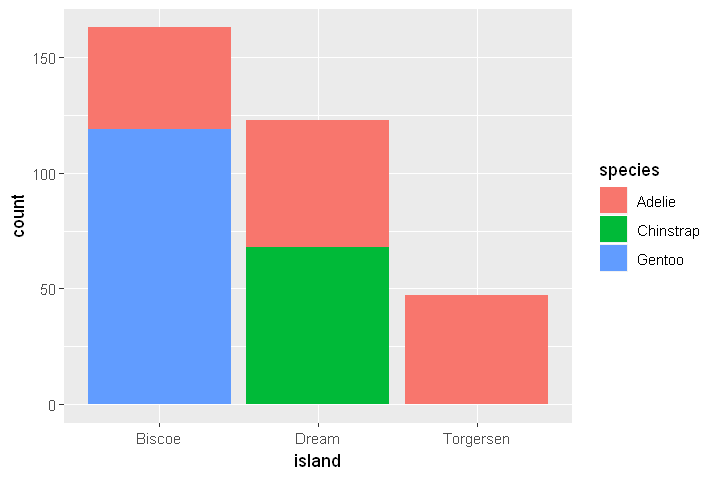

In [41]:
ggplot(penguins, aes(x = island, fill = species))+ geom_bar()

#### Relative frequency plot

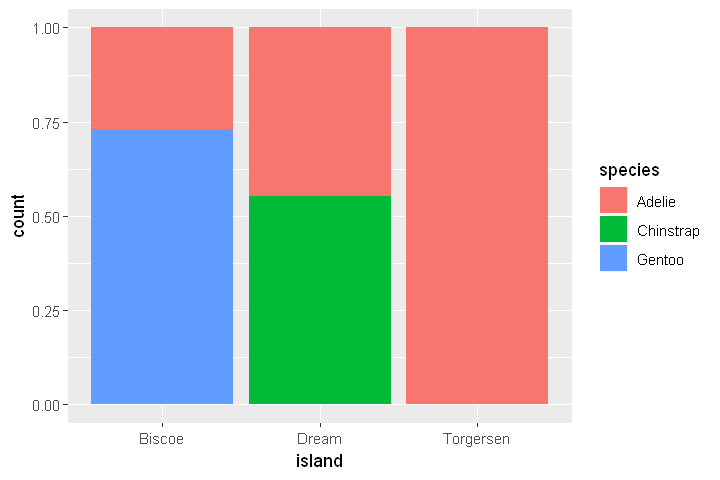

In [42]:
ggplot(penguins, aes(x = island, fill = species)) + geom_bar(position = "fill")

This grapgh is more useful for comparing species
distributions across islands since it’s not affected by the unequal numbers of
penguins across the islands. Using this plot we can see that Gentoo
penguins all live on Biscoe island and make up roughly 75% of the
penguins on that island, Chinstrap all live on Dream island and make up
roughly 50% of the penguins on that island, and Adelie live on all three
islands and make up all of the penguins on Torgersen.

### Saving the Plots

Saving 7 x 7 in image


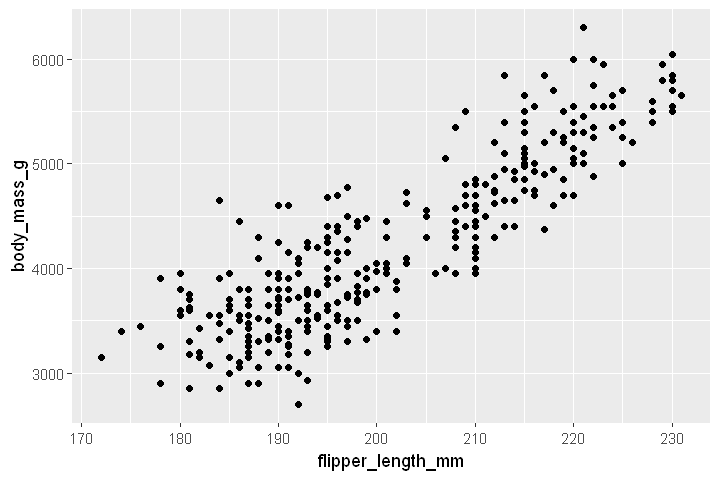

In [43]:
ggplot(penguins, aes(x = flipper_length_mm, y = body_mass_g)) +
 geom_point(na.rm = TRUE)
ggsave(filename = "penguin-plot.png")